# 🏭 Project 13: Visual Quality Control on Casting Defect Dataset
## 📓 Notebook 1: Khám Phá Dữ Liệu (EDA) & Data Augmentation (Tuần 1)

> **Mục tiêu:**
> - Tải và giải nén tập dữ liệu Casting Defect từ Kaggle (~830MB, 7.348 ảnh).
> - Phân tích phân phối lớp (Đạt chuẩn OK vs Khuyết tật Defect).
> - Trực quan hóa hình ảnh thực tế của phôi đúc kim loại.
> - Chia tập dữ liệu chuẩn tỷ lệ **70% Train / 15% Val / 15% Test** (Stratified Split).
> - Xây dựng Pipeline Data Augmentation chuyên biệt cho chi tiết đúc (chỉ áp dụng trên Train).


In [1]:
!nvidia-smi


Tue Sep 22 08:33:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   68C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# 1. Cài đặt thư viện kaggle
!pip install -q kaggle

# 2. Chọn và tải file kaggle.json từ máy tính lên Colab
from google.colab import files
print("Hãy bấm nút 'Choose Files' bên dưới và chọn file kaggle.json từ máy của bạn:")
files.upload()

# 3. Cấu hình quyền bảo mật cho token
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 4. Tải dataset Casting Defect (~830MB - mất khoảng 15-30 giây)
!kaggle datasets download -d ravirajsinh45/real-life-industrial-dataset-of-casting-product

# 5. Giải nén vào thư mục data
!unzip -q real-life-industrial-dataset-of-casting-product.zip -d data/
print(" Hoàn tất tải và giải nén dữ liệu Casting Defect!")


Hãy bấm nút 'Choose Files' bên dưới và chọn file kaggle.json từ máy của bạn:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
100% 100M/100M [00:06<00:00, 16.8MB/s]

 Hoàn tất tải và giải nén dữ liệu Casting Defect!


In [3]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Cố định Seed để kết quả chia tập và thực nghiệm có tính tái lập (Reproducibility)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Đã nạp đầy đủ các thư viện!")


Đã nạp đầy đủ các thư viện!


In [4]:
# Tự động tìm đường dẫn chứa ảnh trong thư mục data vừa giải nén
base_path = "data"
for root, dirs, files_list in os.walk("data"):
    if any("def_front" in d for d in dirs) and any("ok_front" in d for d in dirs):
        base_path = root
        break

print("Thư mục chứa ảnh:", base_path)

# Thu thập toàn bộ đường dẫn ảnh của 2 nhãn
def_images = glob.glob(os.path.join(base_path, "**/*def_front*/**/*.jpeg"), recursive=True) + \
             glob.glob(os.path.join(base_path, "**/*def_front*/**/*.jpg"), recursive=True)

ok_images = glob.glob(os.path.join(base_path, "**/*ok_front*/**/*.jpeg"), recursive=True) + \
            glob.glob(os.path.join(base_path, "**/*ok_front*/**/*.jpg"), recursive=True)

print(f"Tổng số ảnh LỖI (Defective): {len(def_images)}")
print(f"Tổng số ảnh ĐẠT (OK):        {len(ok_images)}")
print(f" Tổng cộng:                 {len(def_images) + len(ok_images)} ảnh")


Thư mục chứa ảnh: data/casting_data/casting_data/train
Tổng số ảnh LỖI (Defective): 3758
Tổng số ảnh ĐẠT (OK):        2875
 Tổng cộng:                 6633 ảnh


/tmp/ipykernel_2373/1188677768.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=counts, palette=colors, ax=axes[0])


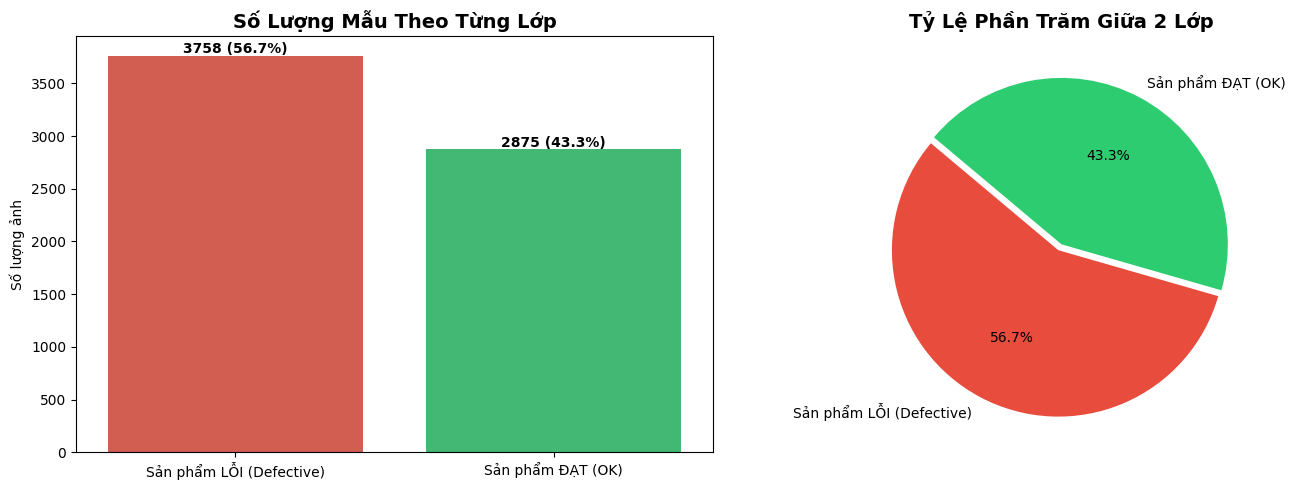

In [5]:
labels = ['Sản phẩm LỖI (Defective)', 'Sản phẩm ĐẠT (OK)']
counts = [len(def_images), len(ok_images)]
colors = ['#E74C3C', '#2ECC71']  # Đỏ cho lỗi, Xanh cho đạt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ cột
sns.barplot(x=labels, y=counts, palette=colors, ax=axes[0])
axes[0].set_title("Số Lượng Mẫu Theo Từng Lớp", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Số lượng ảnh")
for i, v in enumerate(counts):
    axes[0].text(i, v + 25, f"{v} ({v/sum(counts)*100:.1f}%)", ha='center', fontweight='bold')

# Biểu đồ tròn
axes[1].pie(counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140, explode=(0.04, 0))
axes[1].set_title("Tỷ Lệ Phần Trăm Giữa 2 Lớp", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


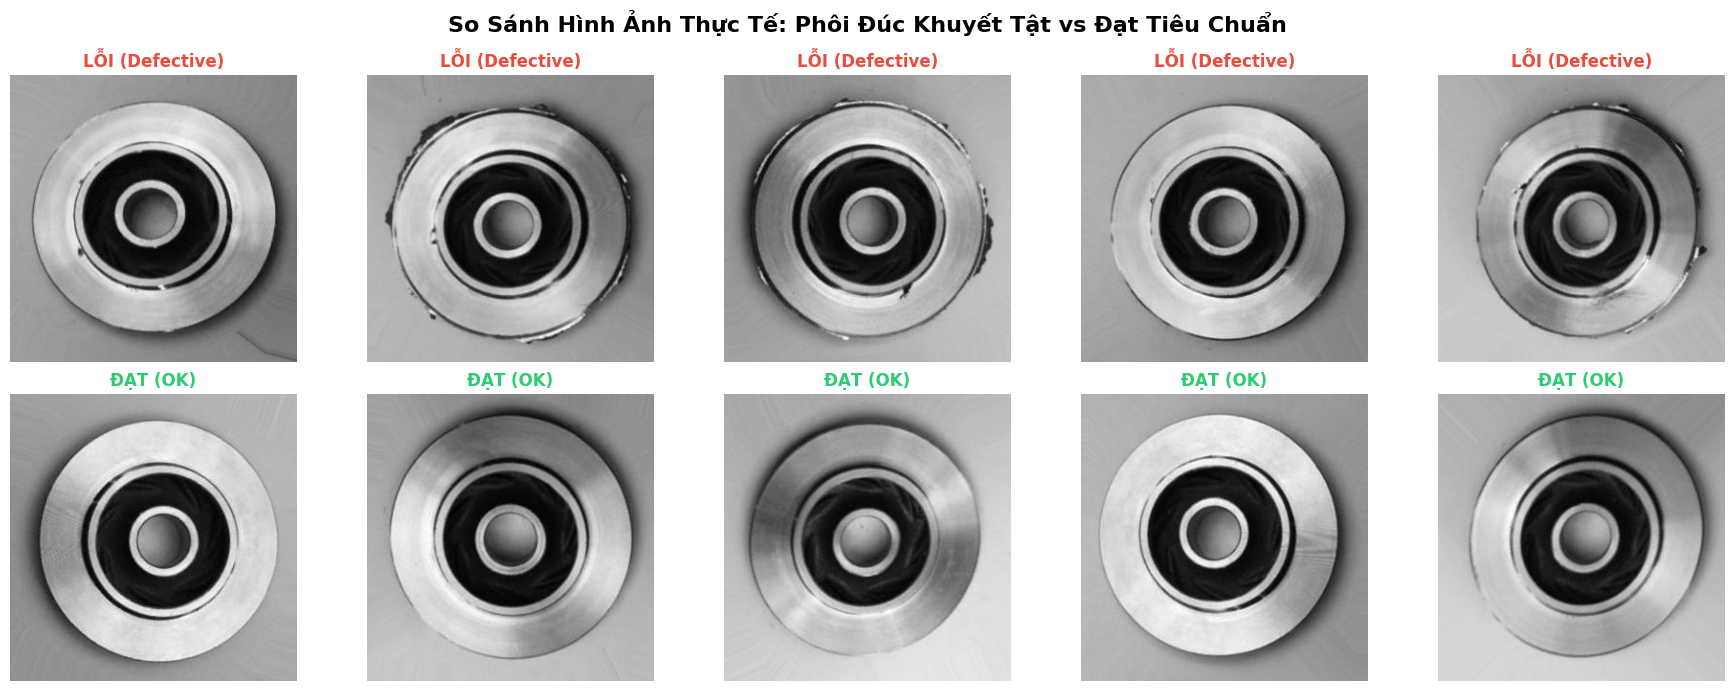

In [6]:
# Lấy ngẫu nhiên 5 ảnh lỗi và 5 ảnh đạt để quan sát khuyết tật thực tế
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

sample_def = random.sample(def_images, 5)
sample_ok = random.sample(ok_images, 5)

# Hàng 1: 5 ảnh khuyết tật (Defective)
for i, path in enumerate(sample_def):
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img_rgb)
    axes[0, i].set_title("LỖI (Defective)", color='#E74C3C', fontweight='bold', fontsize=12)
    axes[0, i].axis('off')

# Hàng 2: 5 ảnh đạt chuẩn (OK)
for i, path in enumerate(sample_ok):
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[1, i].imshow(img_rgb)
    axes[1, i].set_title("ĐẠT (OK)", color='#2ECC71', fontweight='bold', fontsize=12)
    axes[1, i].axis('off')

plt.suptitle("So Sánh Hình Ảnh Thực Tế: Phôi Đúc Khuyết Tật vs Đạt Tiêu Chuẩn", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


In [7]:
# Tạo bảng dữ liệu chứa toàn bộ đường dẫn ảnh và nhãn
# Nhãn 1: Lỗi (defect), Nhãn 0: Đạt (ok)
data_records = []
for path in def_images:
    data_records.append({'filepath': path, 'label': 1, 'class_name': 'defect'})
for path in ok_images:
    data_records.append({'filepath': path, 'label': 0, 'class_name': 'ok'})

df = pd.DataFrame(data_records)

# 1. Tách tập Train (70%) và tập tạm thời Temp (30%) theo Stratified
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df['label']
)

# 2. Tách tập Temp thành Val (15%) và Test (15%)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label']
)

print(f"📊 Tập Train : {len(train_df)} ảnh ({len(train_df)/len(df)*100:.1f}%)")
print(f"📊 Tập Val   : {len(val_df)} ảnh ({len(val_df)/len(df)*100:.1f}%)")
print(f"📊 Tập Test  : {len(test_df)} ảnh ({len(test_df)/len(df)*100:.1f}%)")

# Lưu lại danh sách để các Notebook sau dùng chung mà không bị lệch tập
os.makedirs("processed_data", exist_ok=True)
train_df.to_csv("processed_data/train.csv", index=False)
val_df.to_csv("processed_data/val.csv", index=False)
test_df.to_csv("processed_data/test.csv", index=False)
print(" Đã lưu cấu hình train.csv, val.csv, test.csv vào thư mục processed_data!")


📊 Tập Train : 4643 ảnh (70.0%)
📊 Tập Val   : 995 ảnh (15.0%)
📊 Tập Test  : 995 ảnh (15.0%)
 Đã lưu cấu hình train.csv, val.csv, test.csv vào thư mục processed_data!


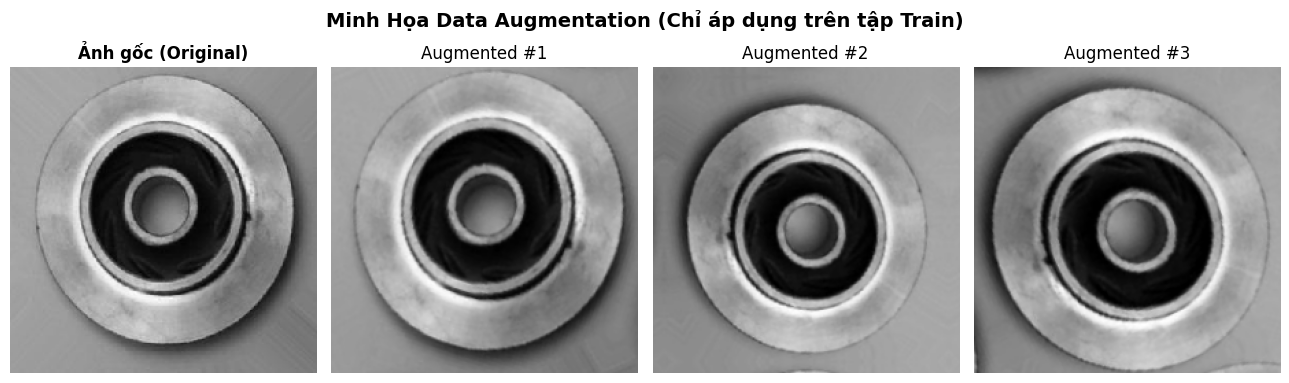

In [8]:
IMG_SIZE = (224, 224)

# Pipeline Augmentation chuyên biệt cho chi tiết cơ khí đúc:
# Xoay nhẹ (+-15 độ), lật ngang/dọc, tương phản ánh sáng phân xưởng, zoom nhẹ
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomContrast(0.1),
    layers.RandomZoom((-0.08, 0.08)),
], name="data_augmentation")

# Trực quan hóa ảnh trước và sau khi Augmentation
sample_path = def_images[0]
sample_img = tf.keras.utils.load_img(sample_path, target_size=IMG_SIZE)
img_array = tf.keras.utils.img_to_array(sample_img)
img_batch = tf.expand_dims(img_array, 0)

plt.figure(figsize=(13, 4))
plt.subplot(1, 4, 1)
plt.imshow(img_array.astype("uint8"))
plt.title("Ảnh gốc (Original)", fontweight='bold')
plt.axis("off")

for i in range(3):
    aug_img = data_augmentation(img_batch)
    plt.subplot(1, 4, i + 2)
    plt.imshow(aug_img[0].numpy().astype("uint8"))
    plt.title(f"Augmented #{i+1}")
    plt.axis("off")

plt.suptitle("Minh Họa Data Augmentation (Chỉ áp dụng trên tập Train)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
